<a href="https://colab.research.google.com/github/carlosvasquez3/modelo-rendimiento-agricola/blob/main/B_preparacion_datos_EVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análisis y predicción del rendimiento agrícola con datos EVA

En este notebook se desarrolla el proceso de preparación, modelamiento, evaluación y despliegue de un modelo para estimar el rendimiento agrícola a partir de los datos de las Evaluaciones Agropecuarias Municipales EVA.

El análisis parte de la base original y comprende la revisión de calidad, selección y transformación de variables, comparación de modelos de regresión, ajuste de hiperparámetros y evaluación con datos que no participaron en el entrenamiento. Finalmente, se serializan los componentes necesarios para integrar el modelo seleccionado en una aplicación desarrollada con Streamlit.

## Carga de datos

In [66]:
# Importe de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para trabajar con archivos (ZIP) desde GitHub
import requests
import zipfile
from io import BytesIO

# Para evitar mensajes innecesarios durante el análisis
import warnings
warnings.filterwarnings("ignore")

In [67]:
# URL del archivo ZIP almacenado en GitHub
url = "https://raw.githubusercontent.com/carlosvasquez3/modelo-rendimiento-agricola/main/A_base_datos_original_EVA.zip"

# Descargar el archivo ZIP
respuesta = requests.get(url)

# Abrir el ZIP y tomar el único archivo que contiene
with zipfile.ZipFile(BytesIO(respuesta.content)) as zip_file:
    archivo = zip_file.namelist()[0]

    # Leer el archivo CSV y guardarlo en un DataFrame
    df = pd.read_csv(zip_file.open(archivo))

# Visualizar los primeros registros
df.head()

,Código Dane departamento,Departamento,Código Dane municipio,Municipio,Grupo cultivo,Subgrupo,Cultivo,Desagregación cultivo,Año,Periodo,Área sembrada,Área cosechada,Producción,Rendimiento,Ciclo del cultivo,Estado físico del cultivo,Código del cultivo,Nombre científico del cultivo
0,5,Antioquia,5001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2021,2021A,"8,00","8,00","128,00","16,00",Transitorio,En fresco,1050600,Apium graveolens
1,5,Antioquia,5001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2021,2021B,"8,00","8,00","152,00","19,00",Transitorio,En fresco,1050600,Apium graveolens
2,5,Antioquia,5001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2022,2022A,"8,00","8,00","127,44","15,93",Transitorio,En fresco,1050600,Apium graveolens
3,5,Antioquia,5001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2022,2022B,"8,00","8,00","152,00","19,00",Transitorio,En fresco,1050600,Apium graveolens
4,5,Antioquia,5001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2023,2023A,"8,00","7,00","133,00","19,00",Transitorio,En fresco,1050600,Apium graveolens


## Revisión inicial de la base de datos

In [68]:
# Dimensiones de la base
print("Filas y columnas", df.shape)

Filas y columnas (166732, 18)


In [69]:
# Tipos de datos
print("\nTipos de datos")
print(df.dtypes)


Tipos de datos
Código Dane departamento          int64
Departamento                     object
Código Dane municipio             int64
Municipio                        object
Grupo cultivo                    object
Subgrupo                         object
Cultivo                          object
Desagregación cultivo            object
Año                               int64
Periodo                          object
Área sembrada                    object
Área cosechada                   object
Producción                       object
Rendimiento                      object
Ciclo del cultivo                object
Estado físico del cultivo        object
Código del cultivo                int64
Nombre científico del cultivo    object
dtype: object


In [70]:
# Valores nulos
print("\nValores nulos")
print(df.isnull().sum())


Valores nulos
Código Dane departamento         0
Departamento                     0
Código Dane municipio            0
Municipio                        0
Grupo cultivo                    0
Subgrupo                         0
Cultivo                          0
Desagregación cultivo            0
Año                              0
Periodo                          0
Área sembrada                    0
Área cosechada                   0
Producción                       0
Rendimiento                      0
Ciclo del cultivo                0
Estado físico del cultivo        0
Código del cultivo               0
Nombre científico del cultivo    0
dtype: int64


La base contiene 166.732 registros y 18 variables. No se encontraron valores nulos en ninguna de las columnas.

Durante la revisión de los tipos de datos se identificó que las variables Área sembrada, Área cosechada, Producción y Rendimiento fueron cargadas como texto, por lo que será necesario convertirlas a formato numérico durante la preparación de los datos.

In [71]:
# Variables que deben ser numéricas
columnas_numericas = [
    "Área sembrada",
    "Área cosechada",
    "Producción",
    "Rendimiento"
]

# Convertir únicamente las variables que todavía están como texto
for columna in columnas_numericas:
    if df[columna].dtype == "object":
        df[columna] = (
            df[columna]
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )

# Revisar los tipos de datos
print(df[columnas_numericas].dtypes)

Área sembrada     float64
Área cosechada    float64
Producción        float64
Rendimiento       float64
dtype: object


Durante la revisión inicial se identificó que Área sembrada, Área cosechada, Producción y Rendimiento estaban almacenadas como variables de tipo object, aunque por su naturaleza corresponden a variables numéricas.

Por esta razón se realizó la conversión de estas columnas a float64, conservando sus valores decimales. Después del ajuste, la base cuenta con 8 variables almacenadas como numéricas y 10 como categóricas.

También se verificó que la base contiene 166.732 registros y que no presenta valores nulos.

## Selección de variables para el modelo

In [72]:
# Selección inicial de variables
df_modelo = df[
    ["Departamento", "Grupo cultivo", "Periodo", "Rendimiento"]
].copy()

# Convertir el periodo original en un tipo de periodo
periodo_texto = (
    df_modelo["Periodo"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_modelo["Tipo periodo"] = pd.NA

df_modelo.loc[
    periodo_texto.str.fullmatch(r"\d{4}A"),
    "Tipo periodo"
] = "A"

df_modelo.loc[
    periodo_texto.str.fullmatch(r"\d{4}B"),
    "Tipo periodo"
] = "B"

df_modelo.loc[
    periodo_texto.str.fullmatch(r"\d{4}"),
    "Tipo periodo"
] = "Completo"

# Verificar que todos los periodos hayan sido clasificados
assert df_modelo["Tipo periodo"].notna().all(), (
    "Existen periodos que no pudieron clasificarse."
)

# Conservar las cuatro variables definitivas
df_modelo = df_modelo[
    [
        "Departamento",
        "Grupo cultivo",
        "Tipo periodo",
        "Rendimiento"
    ]
].copy()

display(df_modelo.head())
display(df_modelo["Tipo periodo"].value_counts())

,Departamento,Grupo cultivo,Tipo periodo,Rendimiento
0,Antioquia,Hortalizas,A,16.00
1,Antioquia,Hortalizas,B,19.00
2,Antioquia,Hortalizas,A,15.93
3,Antioquia,Hortalizas,B,19.00
4,Antioquia,Hortalizas,A,19.00


,count
Tipo periodo,
Completo,65286
A,53065
B,48381


Se conservaron Departamento, Grupo cultivo, Tipo periodo y Rendimiento. La variable Tipo periodo se construyó a partir de Periodo, clasificando los registros terminados en A y B como periodos semestrales y aquellos que contienen únicamente el año como periodos completos.

Esta transformación permitió conservar la diferencia entre los ciclos agrícolas sin incorporar cada año como una categoría independiente. Como resultado, se obtuvieron 65.286 registros de periodo Completo, 53.065 del periodo A y 48.381 del periodo B.

El conjunto final mantiene tres variables categóricas de entrada y una variable numérica de salida. La predicción representa el rendimiento esperado para la combinación seleccionada y no el promedio de las observaciones históricas.

In [73]:
# Revisamos tipo
print(df_modelo.dtypes)

Departamento      object
Grupo cultivo     object
Tipo periodo      object
Rendimiento      float64
dtype: object


## ydata-profiling

In [74]:
!pip install ydata-profiling -q

In [75]:
# Importar la librería
from ydata_profiling import ProfileReport

# Generar el reporte de perfilamiento
reporte = ProfileReport(
    df_modelo,
    title="Perfilamiento de datos EVA"
)

# Guardar el reporte en formato HTML
reporte.to_file("C_reporte_ydata_EVA.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:01<00:00,  3.75it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Revisión de duplicados

Se revisan los registros duplicados sobre la base original para determinar si las repeticiones identificadas durante el perfilamiento corresponden realmente a filas completamente iguales.

In [76]:
# Contar registros completamente duplicados en la base original
duplicados_original = df.duplicated().sum()

# Número de registros duplicados
print("Duplicados exactos en la base original", duplicados_original)

Duplicados exactos en la base original 0


### Revisión de registros duplicados

Durante el perfilamiento se identificaron combinaciones repetidas dentro de las cuatro variables seleccionadas. Para comprobar si correspondían a duplicados reales, se realizó una validación sobre las 18 variables de la base original.

La revisión mostró que no existen registros completamente duplicados. Por esta razón, no se realizó ninguna eliminación por duplicidad y se conservaron todos los registros disponibles.

## Codificación de variables

Las variables Departamento, Grupo cultivo y Tipo periodo son categóricas, por lo que deben transformarse a una representación numérica antes del entrenamiento.

Se utilizará One Hot Encoding porque sus categorías no presentan un orden natural. Esta técnica genera variables binarias para cada categoría y permite que los modelos procesen la información sin asignar relaciones jerárquicas que no existen.

In [77]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Variables de entrada
X = df_modelo[
    ["Departamento", "Grupo cultivo", "Tipo periodo"]
]

# Variable objetivo
y = df_modelo["Rendimiento"]

columnas_categoricas = [
    "Departamento",
    "Grupo cultivo",
    "Tipo periodo"
]

preprocesador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            columnas_categoricas
        )
    ]
)

print("Variables de entrada:", X.shape)
print("Variable objetivo:", y.shape)

Variables de entrada: (166732, 3)
Variable objetivo: (166732,)


### Análisis

Se definieron Departamento, Grupo cultivo y Tipo periodo como variables de entrada, mientras que Rendimiento corresponde a la variable objetivo.

La codificación se integrará dentro del pipeline y se ajustará únicamente con los datos de entrenamiento. De esta manera, las categorías del conjunto de prueba no intervienen en el aprendizaje del codificador y se evita la fuga de información.

# Modelamiento del rendimiento agrícola

En esta etapa se construyen y comparan diferentes modelos para estimar el Rendimiento a partir de Departamento, Grupo cultivo y Tipo periodo.

El proceso incluye cinco modelos clásicos y tres modelos de ensamble. Todos se evalúan mediante validación cruzada de diez particiones sobre el 70 % destinado al entrenamiento. El 30 % restante se mantiene separado y se utiliza únicamente durante la evaluación final.

## Decisiones metodológicas

El problema corresponde a aprendizaje supervisado de regresión porque Rendimiento es una variable numérica continua. Aunque la regresión logística fue uno de los modelos estudiados en el curso, no se implementa porque está orientada a problemas de clasificación. Convertir el rendimiento en categorías modificaría el problema planteado y ocasionaría pérdida de información.

Los conceptos de máquina de soporte vectorial y redes neuronales se aplican mediante sus versiones para regresión, LinearSVR y MLPRegressor. Los cinco modelos clásicos seleccionados son regresión lineal, árbol de regresión, KNN Regressor, máquina de soporte vectorial y red neuronal MLP.

Los ensambles se implementan mediante VotingRegressor, BaggingRegressor y GradientBoostingRegressor. Su inclusión permite comprobar si la combinación de varios estimadores mejora el desempeño de los modelos individuales.

La métrica principal es RMSE porque expresa el error en las mismas unidades del rendimiento y penaliza con mayor intensidad los errores grandes. MAE y R² se utilizan como métricas complementarias.

La conservación de cuatro variables responde al alcance académico, al tiempo disponible y a la recomendación realizada por el profesor. Por esta razón, los resultados se interpretan como una aproximación basada en factores territoriales, productivos y estacionales. No pretenden explicar todos los factores agronómicos que pueden afectar el rendimiento.

In [78]:
# Librerías y configuración general
import warnings
import zipfile
from io import BytesIO
from time import perf_counter

import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    BaggingRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

SEMILLA = 42
N_PARTICIONES = 10

# Se usan dos procesos para evitar un consumo excesivo de memoria en Colab.
# Si el entorno tiene poca memoria, puede cambiarse a 1.
N_JOBS = 2

In [79]:
# Controles de calidad antes del modelamiento
columnas_modelo = [
    "Departamento",
    "Grupo cultivo",
    "Tipo periodo",
    "Rendimiento"
]

tipos_esperados = {"A", "B", "Completo"}

assert set(df_modelo["Tipo periodo"].unique()) == tipos_esperados, ("Los tipos de periodo no corresponden a A, B y Completo.")
assert df_modelo.columns.tolist() == columnas_modelo
assert df_modelo.isna().sum().sum() == 0, "Existen valores nulos que deben revisarse."
assert np.isfinite(df_modelo["Rendimiento"]).all(), "Hay valores no finitos en la variable objetivo."
assert (df_modelo["Rendimiento"] >= 0).all(), "Hay rendimientos negativos que deben revisarse."

resumen_objetivo = df_modelo["Rendimiento"].describe().to_frame("Rendimiento")
display(resumen_objetivo)

print("Registros con rendimiento igual a cero:", (df_modelo["Rendimiento"] == 0).sum())
print("Estos registros se conservan de acuerdo con las decisiones del punto 3.")

,Rendimiento
count,166732.000000
mean,10.601229
std,15.573952
min,0.000000
25%,1.800000
50%,6.000000
75%,13.000000
max,253.000000


Registros con rendimiento igual a cero: 7116
Estos registros se conservan de acuerdo con las decisiones del punto 3.


## Separación de entrenamiento y prueba

La división se realiza una sola vez, utilizando 70 % para entrenamiento y 30 % para prueba. La validación cruzada se aplica exclusivamente sobre el conjunto de entrenamiento. El conjunto de prueba se conserva sin consultar hasta el punto 5.

Las variables de entrada son categóricas. Por esta razón se transforman con One Hot Encoding dentro de un **Pipeline**. Esta ubicación es importante porque el codificador se ajusta nuevamente dentro de cada partición de validación cruzada y evita que las categorías del subconjunto de validación aporten información al entrenamiento.

In [80]:
variables_entrada = ["Departamento", "Grupo cultivo", "Tipo periodo"]
variable_objetivo = "Rendimiento"

X = df_modelo[variables_entrada]
y = df_modelo[variable_objetivo]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEMILLA,
)

preprocesador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            variables_entrada,
        )
    ],
    remainder="drop",
)

cv = KFold(
    n_splits=N_PARTICIONES,
    shuffle=True,
    random_state=SEMILLA,
)

print("Registros de entrenamiento:", X_train.shape[0])
print("Registros reservados para prueba:", X_test.shape[0])
print("Particiones de validación cruzada:", N_PARTICIONES)

Registros de entrenamiento: 116712
Registros reservados para prueba: 50020
Particiones de validación cruzada: 10


## Función común de evaluación

Todos los modelos se evalúan con las mismas diez particiones y las mismas métricas. Se reportan el promedio y la desviación estándar para analizar tanto el desempeño como su estabilidad durante la validación cruzada.

El RMSE se utiliza como métrica principal y un valor menor representa un mejor resultado. El MAE muestra el tamaño promedio del error absoluto, mientras que R² indica la proporción de variabilidad del rendimiento explicada por el modelo.

In [81]:
metricas = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}


def construir_pipeline(modelo):
    return Pipeline(
        steps=[
            ("preprocesador", preprocesador),
            ("modelo", modelo),
        ]
    )


def evaluar_modelos(modelos, tipo):
    filas = []
    pipelines = {}

    for nombre, modelo in modelos.items():
        print(f"Evaluando: {nombre}")
        inicio = perf_counter()
        pipeline = construir_pipeline(modelo)

        resultados = cross_validate(
            estimator=pipeline,
            X=X_train,
            y=y_train,
            cv=cv,
            scoring=metricas,
            n_jobs=N_JOBS,
            error_score="raise",
            return_train_score=False,
        )

        filas.append(
            {
                "Tipo": tipo,
                "Modelo": nombre,
                "RMSE promedio": -resultados["test_RMSE"].mean(),
                "RMSE desviación": resultados["test_RMSE"].std(),
                "MAE promedio": -resultados["test_MAE"].mean(),
                "MAE desviación": resultados["test_MAE"].std(),
                "R2 promedio": resultados["test_R2"].mean(),
                "R2 desviación": resultados["test_R2"].std(),
                "Tiempo segundos": perf_counter() - inicio,
            }
        )
        pipelines[nombre] = pipeline

    tabla = pd.DataFrame(filas).sort_values("RMSE promedio").reset_index(drop=True)
    return tabla, pipelines

## Modelos clásicos

Se comparan cinco modelos con comportamientos distintos:

1. **Regresión lineal:** funciona como línea base e identifica relaciones aditivas entre las categorías y el rendimiento.
2. **Árbol de regresión:** captura relaciones no lineales e interacciones entre las variables.
3. **KNN Regressor:** estima el rendimiento a partir de observaciones cercanas según su representación categórica.
4. **LinearSVR:** aplica el principio de máquina de soporte vectorial a una variable continua. Se utiliza una versión lineal por su viabilidad computacional con más de cien mil registros.
5. **Red neuronal MLP:** aprende relaciones no lineales mediante una capa oculta y utiliza detención temprana para limitar el sobreajuste.

KNN puede requerir más tiempo que los demás modelos porque compara cada observación de validación con una cantidad amplia de registros de entrenamiento. Se conserva para cumplir la comparación de cinco métodos, y su tiempo se reporta como parte del análisis.

In [82]:
modelos_clasicos = {
    "Regresión lineal": LinearRegression(),
    "Árbol de regresión": DecisionTreeRegressor(random_state=SEMILLA),
    "KNN Regressor": KNeighborsRegressor(
        n_neighbors=15,
        weights="distance",
        algorithm="brute",
        n_jobs=1,
    ),
    "Máquina de soporte vectorial": LinearSVR(
        C=1.0,
        epsilon=0.1,
        max_iter=10000,
        random_state=SEMILLA,
    ),
    "Red neuronal MLP": MLPRegressor(
        hidden_layer_sizes=(32,),
        activation="relu",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,
        random_state=SEMILLA,
    ),
}

resultados_clasicos, pipelines_clasicos = evaluar_modelos(
    modelos=modelos_clasicos,
    tipo="Clásico",
)

display(resultados_clasicos.round(4))

Evaluando: Regresión lineal
Evaluando: Árbol de regresión
Evaluando: KNN Regressor
Evaluando: Máquina de soporte vectorial
Evaluando: Red neuronal MLP


,Tipo,Modelo,RMSE promedio,RMSE desviación,MAE promedio,MAE desviación,R2 promedio,R2 desviación,Tiempo segundos
0,Clásico,Árbol de regresión,13.5988,0.2131,7.1164,0.0682,0.2396,0.0095,5.4519
1,Clásico,Red neuronal MLP,13.6083,0.2151,7.1472,0.0872,0.2386,0.0087,161.5945
2,Clásico,KNN Regressor,13.9985,0.2194,7.3023,0.1026,0.1941,0.0179,278.9961
3,Clásico,Regresión lineal,14.0402,0.2225,7.6583,0.0688,0.1895,0.0055,4.6955
4,Clásico,Máquina de soporte vectorial,15.2940,0.2887,6.6303,0.0948,0.0384,0.0085,4.4171


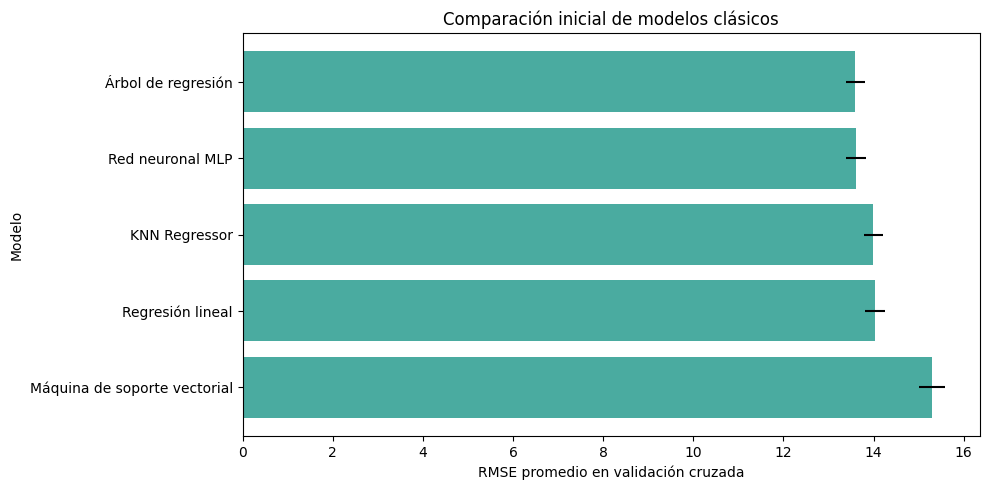

In [83]:
# Comparación visual de los cinco modelos clásicos
tabla_grafica = resultados_clasicos.sort_values("RMSE promedio")

plt.figure(figsize=(10, 5))
plt.barh(
    tabla_grafica["Modelo"],
    tabla_grafica["RMSE promedio"],
    xerr=tabla_grafica["RMSE desviación"],
    color="#2a9d8f",
    alpha=0.85,
)
plt.xlabel("RMSE promedio en validación cruzada")
plt.ylabel("Modelo")
plt.title("Comparación inicial de modelos clásicos")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Resultados de los modelos clásicos

El árbol de regresión obtuvo el menor RMSE promedio con 13,5988, seguido por la red neuronal MLP con 13,6083. La diferencia entre ambos fue de 0,0095 y sus desviaciones también fueron similares, lo que muestra un desempeño cercano y estable entre las particiones.

KNN alcanzó un RMSE de 13,9985 y presentó el mayor tiempo de evaluación, con aproximadamente 279 segundos. La regresión lineal obtuvo 14,0402 y la máquina de soporte vectorial 15,2940.

El árbol presentó la mejor combinación entre RMSE y tiempo de ejecución, pues completó la evaluación en aproximadamente 5,45 segundos. Este resultado sugiere que existen interacciones no lineales entre las variables que el árbol logró representar de manera eficiente.

## Modelos de ensamble

Los ensambles combinan varios estimadores con el propósito de obtener predicciones más estables o reducir el error:

- **Votación:** promedia las predicciones de una regresión lineal, un árbol y una máquina de soporte vectorial.
- **Bagging:** entrena varios árboles sobre muestras diferentes del conjunto de entrenamiento y promedia sus resultados.
- **Boosting:** construye árboles de manera secuencial, de modo que cada estimador intenta corregir los errores de los anteriores.

In [84]:
modelo_votacion = VotingRegressor(
    estimators=[
        ("lineal", LinearRegression()),
        (
            "arbol",
            DecisionTreeRegressor(
                max_depth=12,
                min_samples_leaf=5,
                random_state=SEMILLA,
            ),
        ),
        (
            "svr",
            LinearSVR(
                C=1.0,
                epsilon=0.1,
                max_iter=10000,
                random_state=SEMILLA,
            ),
        ),
    ],
)

modelos_ensemble = {
    "Votación": modelo_votacion,
    "Bagging": BaggingRegressor(
        estimator=DecisionTreeRegressor(
            min_samples_leaf=3,
            random_state=SEMILLA,
        ),
        n_estimators=50,
        max_samples=0.80,
        bootstrap=True,
        n_jobs=1,
        random_state=SEMILLA,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.10,
        max_depth=3,
        random_state=SEMILLA,
    ),
}

resultados_ensemble, pipelines_ensemble = evaluar_modelos(
    modelos=modelos_ensemble,
    tipo="Ensamble",
)

display(resultados_ensemble.round(4))

Evaluando: Votación
Evaluando: Bagging
Evaluando: Gradient Boosting


,Tipo,Modelo,RMSE promedio,RMSE desviación,MAE promedio,MAE desviación,R2 promedio,R2 desviación,Tiempo segundos
0,Ensamble,Bagging,13.5993,0.2119,7.1169,0.0671,0.2395,0.0095,118.4211
1,Ensamble,Gradient Boosting,13.7412,0.2204,7.2866,0.0643,0.2236,0.0081,28.9471
2,Ensamble,Votación,13.9573,0.2451,6.9500,0.0717,0.1991,0.0051,6.0913


### Resultados de los modelos de ensamble

Bagging obtuvo el mejor resultado entre los ensambles con un RMSE promedio de 13,5993 y una desviación de 0,2119. Su desempeño fue prácticamente igual al árbol individual, que alcanzó 13,5988, por lo que la combinación de varios árboles no produjo una mejora en la métrica principal.

Gradient Boosting obtuvo un RMSE de 13,7412 y Voting Regressor alcanzó 13,9573. Aunque Voting presentó un MAE menor, su RMSE y R² fueron inferiores a los resultados del árbol, Bagging y la MLP.

Bagging mantuvo un comportamiento estable, pero requirió aproximadamente 118 segundos frente a los 5,45 segundos del árbol. Por esta razón, el árbol continúa como el mejor candidato inicial.

In [85]:
# Comparación conjunta antes del ajuste de hiperparámetros
resultados_iniciales = (
    pd.concat([resultados_clasicos, resultados_ensemble], ignore_index=True)
    .sort_values("RMSE promedio")
    .reset_index(drop=True)
)

display(resultados_iniciales.round(4))

mejor_inicial = resultados_iniciales.iloc[0]
print("Mejor resultado inicial según RMSE:", mejor_inicial["Modelo"])
print("RMSE promedio:", round(mejor_inicial["RMSE promedio"], 4))
print("Desviación del RMSE:", round(mejor_inicial["RMSE desviación"], 4))

,Tipo,Modelo,RMSE promedio,RMSE desviación,MAE promedio,MAE desviación,R2 promedio,R2 desviación,Tiempo segundos
0,Clásico,Árbol de regresión,13.5988,0.2131,7.1164,0.0682,0.2396,0.0095,5.4519
1,Ensamble,Bagging,13.5993,0.2119,7.1169,0.0671,0.2395,0.0095,118.4211
2,Clásico,Red neuronal MLP,13.6083,0.2151,7.1472,0.0872,0.2386,0.0087,161.5945
3,Ensamble,Gradient Boosting,13.7412,0.2204,7.2866,0.0643,0.2236,0.0081,28.9471
4,Ensamble,Votación,13.9573,0.2451,6.9500,0.0717,0.1991,0.0051,6.0913
5,Clásico,KNN Regressor,13.9985,0.2194,7.3023,0.1026,0.1941,0.0179,278.9961
6,Clásico,Regresión lineal,14.0402,0.2225,7.6583,0.0688,0.1895,0.0055,4.6955
7,Clásico,Máquina de soporte vectorial,15.2940,0.2887,6.6303,0.0948,0.0384,0.0085,4.4171


Mejor resultado inicial según RMSE: Árbol de regresión
RMSE promedio: 13.5988
Desviación del RMSE: 0.2131


## Ajuste de hiperparámetros

El árbol de regresión se seleccionó para el ajuste porque obtuvo el menor RMSE en la comparación inicial. La búsqueda se realizó mediante GridSearchCV, utilizando las mismas diez particiones y el RMSE como criterio de selección.

Se evaluaron nueve combinaciones, equivalentes a 90 ajustes sobre el conjunto de entrenamiento.

| Hiperparámetro | Qué controla | Valores evaluados | Justificación del rango |
|---|---|---|---|
| `max_depth` | Limita la profundidad y complejidad del árbol. | `None`, 10 y 20 | Se compara el árbol sin restricción con dos profundidades moderadas para comprobar si limitar su complejidad mejora la generalización. |
| `min_samples_leaf` | Define la cantidad mínima de observaciones permitida en cada hoja. | 1, 5 y 10 | Se compara la configuración inicial con dos niveles de regularización que evitan hojas excesivamente específicas. |


In [86]:
pipeline_arbol = construir_pipeline(
    DecisionTreeRegressor(random_state=SEMILLA)
)

grilla_parametros = {
    "modelo__max_depth": [None, 10, 20],
    "modelo__min_samples_leaf": [1, 5, 10],
}

busqueda_arbol = GridSearchCV(
    estimator=pipeline_arbol,
    param_grid=grilla_parametros,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=N_JOBS,
    refit=True,
    return_train_score=True,
    verbose=1,
)

inicio_ajuste = perf_counter()

busqueda_arbol.fit(X_train, y_train)

tiempo_ajuste = perf_counter() - inicio_ajuste

print("Mejores hiperparámetros:",busqueda_arbol.best_params_)
print("Mejor RMSE promedio en validación:",round(-busqueda_arbol.best_score_, 4))
print("Tiempo total del ajuste en segundos:",round(tiempo_ajuste, 2))

Fitting 10 folds for each of 9 candidates, totalling 90 fits
Mejores hiperparámetros: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 1}
Mejor RMSE promedio en validación: 13.5988
Tiempo total del ajuste en segundos: 37.47


In [87]:
# Resultados completos de la búsqueda
resultados_grid = pd.DataFrame(
    busqueda_arbol.cv_results_
)

columnas_resultados_grid = [
    "param_modelo__max_depth",
    "param_modelo__min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "rank_test_score",
]

tabla_grid = resultados_grid[
    columnas_resultados_grid
].copy()

tabla_grid["RMSE validación"] = (
    -tabla_grid["mean_test_score"]
)

tabla_grid["RMSE entrenamiento"] = (
    -tabla_grid["mean_train_score"]
)

tabla_grid = tabla_grid.sort_values(
    "rank_test_score"
)

display(
    tabla_grid[
        [
            "param_modelo__max_depth",
            "param_modelo__min_samples_leaf",
            "RMSE entrenamiento",
            "RMSE validación",
            "std_test_score",
            "rank_test_score",
        ]
    ].round(4)
)

,param_modelo__max_depth,param_modelo__min_samples_leaf,RMSE entrenamiento,RMSE validación,std_test_score,rank_test_score
0,None,1,13.5667,13.5988,0.2131,1
2,None,10,13.5676,13.5990,0.2128,2
1,None,5,13.5670,13.5990,0.2130,3
6,20,1,13.5766,13.6058,0.2129,4
7,20,5,13.5768,13.6060,0.2129,5
8,20,10,13.5773,13.6065,0.2128,6
4,10,5,13.6655,13.6809,0.2134,7
3,10,1,13.6654,13.6809,0.2135,8
5,10,10,13.6657,13.6812,0.2135,9


### Interpretación del ajuste

La mejor configuración mantuvo `max_depth=None` y `min_samples_leaf=1`, con un RMSE de validación de 13,5988. Estos valores corresponden a la configuración inicial, por lo que el ajuste no encontró una alternativa que mejorara su desempeño.

El RMSE de entrenamiento fue 13,5667 y el de validación 13,5988. La diferencia de 0,0321 es pequeña frente a la desviación de 0,2131, por lo que no se observa una separación marcada entre ambos resultados.

Aumentar `min_samples_leaf` a 5 o 10 produjo cambios mínimos cuando la profundidad no tenía restricción. En cambio, limitar `max_depth` a 20 aumentó ligeramente el error y reducirla a 10 elevó el RMSE hasta aproximadamente 13,681. Esto indica que las restricciones evaluadas redujeron la capacidad del árbol sin aportar una mejora en su generalización.

Aunque la búsqueda no superó el resultado inicial, permitió comprobar que la configuración original era la más adecuada dentro del rango analizado.

## Cierre del modelamiento

Durante el modelamiento se compararon cinco modelos clásicos y tres modelos de ensamble mediante el mismo procedimiento de validación cruzada. El árbol de regresión obtuvo el menor RMSE promedio con 13,5988, seguido por Bagging con 13,5993 y la MLP con 13,6083.

Las diferencias entre estos tres modelos fueron pequeñas frente a sus desviaciones entre particiones. Por esta razón, los tres se conservan como candidatos para la evaluación final. El árbol ajustado mantiene la configuración inicial seleccionada por GridSearchCV, mientras que Bagging y la MLP se vuelven a entrenar con todo el conjunto de entrenamiento.

La selección definitiva se realizará con el 30 % reservado para prueba, utilizando nuevamente el RMSE como métrica principal.

# Evaluación

En esta etapa se evaluarán los principales modelos seleccionados durante la fase de modelamiento utilizando el conjunto de prueba reservado previamente.

La evaluación se realizará mediante RMSE, MAE y R². El RMSE se mantiene como métrica principal para seleccionar el modelo final, mientras que MAE y R² se utilizarán como métricas complementarias.

El conjunto de prueba no participó en el entrenamiento, la validación cruzada ni el ajuste de hiperparámetros, por lo que permite evaluar el comportamiento de los modelos frente a datos no utilizados durante las etapas anteriores.

In [88]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# El árbol ajustado ya fue reentrenado por GridSearchCV
arbol_ajustado = busqueda_arbol.best_estimator_

# Entrenar los otros candidatos con todo el conjunto de entrenamiento
bagging_inicial = pipelines_ensemble["Bagging"]
bagging_inicial.fit(X_train, y_train)

mlp_inicial = pipelines_clasicos["Red neuronal MLP"]
mlp_inicial.fit(X_train, y_train)

candidatos_finales = {
    "Árbol ajustado": arbol_ajustado,
    "Bagging": bagging_inicial,
    "MLP inicial": mlp_inicial,
}

resultados_prueba = []

for nombre, modelo in candidatos_finales.items():

    y_pred = modelo.predict(X_test)

    resultados_prueba.append({
        "Modelo": nombre,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_test, y_pred)
        ),
        "R2": r2_score(y_test, y_pred)
    })

resultados_prueba = (
    pd.DataFrame(resultados_prueba)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(resultados_prueba.round(4))

,Modelo,MAE,RMSE,R2
0,Árbol ajustado,7.0839,13.4736,0.2461
1,Bagging,7.0854,13.4747,0.2460
2,MLP inicial,7.0888,13.4894,0.2443


## Análisis de los resultados en prueba

Los tres candidatos presentaron resultados similares en el conjunto de prueba. El árbol ajustado obtuvo el menor RMSE con 13,4736, seguido por Bagging con 13,4747 y la MLP con 13,4894.

El árbol también alcanzó el menor MAE con 7,0839 y el mayor R² con 0,2461. Bagging obtuvo un MAE de 7,0854 y un R² de 0,2460, mientras que la MLP registró un MAE de 7,0888 y un R² de 0,2443.

El RMSE del árbol en prueba fue inferior al promedio de validación cruzada de 13,5988. La diferencia entre ambos resultados se encuentra dentro de la desviación observada durante la validación, lo que indica un comportamiento estable frente a datos que no participaron en el entrenamiento.

Debido a que el RMSE fue definido como métrica principal, se selecciona el árbol como modelo final. Además de presentar el menor error, requiere menos tiempo de entrenamiento y ofrece una estructura más sencilla que Bagging y la red neuronal.

## Despliegue

En esta etapa se selecciona automáticamente el modelo con menor RMSE y se serializan mediante joblib el modelo final, el codificador, el escalador, los datos de referencia y el pipeline completo. Estos archivos permiten reproducir en Streamlit las mismas transformaciones utilizadas durante el entrenamiento.

Aunque One Hot Encoding genera variables binarias entre cero y uno, se conserva MinMaxScaler para mantener el flujo de despliegue planteado en clase. En este caso, el escalador no modifica los valores codificados.

No se utiliza Label Encoder sobre la variable objetivo porque Rendimiento es una variable numérica continua. La aplicación recibe Departamento, Grupo cultivo y Tipo periodo, construye un único registro y genera una predicción directa. El resultado no corresponde a un promedio de años ni de observaciones históricas. en clase. En este caso el escalador no modifica los valores binarios. No se utiliza Label Encoder sobre la variable objetivo porque Rendimiento es una variable numérica continua.

In [89]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Seleccionar automáticamente el modelo con menor RMSE
nombre_modelo_final = resultados_prueba.iloc[0]["Modelo"]
pipeline_final = candidatos_finales[nombre_modelo_final]

print("Modelo seleccionado:", nombre_modelo_final)

# Extraer el codificador y el modelo
encoder_final = (
    pipeline_final
    .named_steps["preprocesador"]
    .named_transformers_["categoricas"]
)

modelo_final = pipeline_final.named_steps["modelo"]

# Ajustar el escalador con los datos de entrenamiento codificados
X_train_codificado = encoder_final.transform(X_train)

if hasattr(X_train_codificado, "toarray"):
    X_train_codificado = X_train_codificado.toarray()

escalador_final = MinMaxScaler()
escalador_final.fit(X_train_codificado)

# Categorías disponibles para la aplicación
datos_referencia = (
    X_train[variables_entrada]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Guardar artefactos
joblib.dump(modelo_final, "modelo_final.joblib")
joblib.dump(encoder_final, "onehot_encoder.joblib")
joblib.dump(escalador_final, "minmax_scaler.joblib")
joblib.dump(datos_referencia, "datos_referencia.joblib")
joblib.dump(
    pipeline_final,
    "pipeline_final_completo.joblib"
)

print("Artefactos guardados correctamente")

Modelo seleccionado: Árbol ajustado
Artefactos guardados correctamente


In [90]:
# Registro que no participó en el entrenamiento
nuevo_registro = X_test.iloc[[0]].copy()

registro_codificado = encoder_final.transform(
    nuevo_registro
)

if hasattr(registro_codificado, "toarray"):
    registro_codificado = registro_codificado.toarray()

registro_escalado = escalador_final.transform(
    registro_codificado
)

prediccion_nueva = modelo_final.predict(
    registro_escalado
)[0]

# Comprobar que coincide con el pipeline completo
prediccion_pipeline = pipeline_final.predict(
    nuevo_registro
)[0]

assert np.isclose(
    prediccion_nueva,
    prediccion_pipeline
), "Las predicciones del pipeline y los artefactos no coinciden."

resultado_prediccion = nuevo_registro.copy()
resultado_prediccion[
    "Rendimiento predicho"
] = prediccion_nueva

resultado_prediccion[
    "Rendimiento real"
] = y_test.loc[nuevo_registro.index]

display(resultado_prediccion)

,Departamento,Grupo cultivo,Tipo periodo,Rendimiento predicho,Rendimiento real
103200,Meta,Frutales,Completo,14.988811,17.0


### Verificación de la predicción

Para comprobar el funcionamiento de los artefactos se seleccionó un registro del conjunto de prueba que no participó en el entrenamiento. El registro corresponde al departamento del Meta, grupo Frutales y tipo de periodo Completo.

El modelo estimó un rendimiento de 14,9888 t/ha, mientras que el valor real registrado fue de 17 t/ha. En este caso particular, la diferencia absoluta fue de aproximadamente 2,01 t/ha.

También se verificó que la predicción obtenida al cargar por separado el codificador, el escalador y el modelo coincidiera con la generada por el pipeline completo. Esta validación confirma que las transformaciones fueron serializadas correctamente y que la aplicación puede reproducir el flujo utilizado durante el entrenamiento.